In [2]:
pip install tf-nightly-gpu

  Using cached Keras_Preprocessing-1.1.2-py2.py3-none-any.whl (42 kB)
  Using cached tb_nightly-2.10.0a20220706-py3-none-any.whl (5.8 MB)
  Using cached keras_nightly-2.10.0.dev2022070607-py2.py3-none-any.whl (1.7 MB)
  Using cached libclang-14.0.1-py2.py3-none-win_amd64.whl (14.2 MB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl (12 kB)
  Using cached absl_py-1.1.0-py3-none-any.whl (123 kB)
  Using cached flatbuffers-2.0-py2.py3-none-any.whl (26 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl (57 kB)
  Using cached opt_einsum-3.3.0-py3-none-any.whl (65 kB)
  Using cached gast-0.4.0-py3-none-any.whl (9.8 kB)
  Using cached termcolor-1.1.0-py3-none-any.whl
  Using cached tf_estimator_nightly-2.10.0.dev2022070608-py2.py3-none-any.whl (438 kB)
  Using cached tensorboard_plugin_wit-1.8.1-py3-none-any.whl (781 kB)
  Using cached google_auth_oauthlib-0.4.6-py2.py3-none-any.whl (18 kB)
  Using cached tensorboard_data_server-0.6.1-py3-none-any.whl (2.4 kB)
  Using cached requests

In [4]:
pip install opencv-python

  Using cached opencv_python-4.6.0.66-cp36-abi3-win_amd64.whl (35.6 MB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
# import libraries

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [2]:
image_size = (128,128)

base_dir = 'C:/Users/LENOVO/Documents/skripsi/program/input/face-mask-12k-images-dataset/Face Mask Dataset/'


train_gen = keras.preprocessing.image.ImageDataGenerator(
    horizontal_flip=True,
    rescale=1./255
)

val_gen = keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

test_gen = keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

train_ds = train_gen.flow_from_directory(base_dir+'Train',target_size=image_size,seed=42)
val_ds = val_gen.flow_from_directory(base_dir+'Validation',target_size=image_size,seed=42)
test_ds = test_gen.flow_from_directory(base_dir+'Test',target_size=image_size,seed=42)

Found 10000 images belonging to 2 classes.
Found 800 images belonging to 2 classes.
Found 992 images belonging to 2 classes.


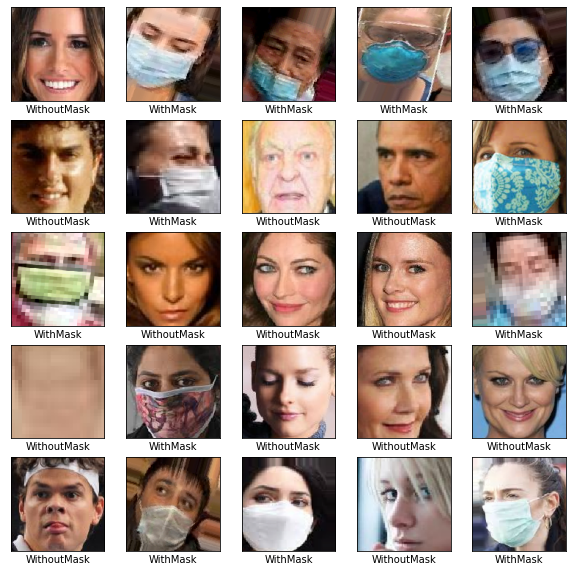

In [3]:
class_names = {v:k for k,v in train_ds.class_indices.items()}
images,labels = next(iter(train_ds))

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(images[i])
    plt.xticks([])
    plt.yticks([])
    plt.xlabel(class_names[labels[i][1]])

plt.show()

In [4]:
# we use VGG19 model for mask detection

base_model = keras.applications.VGG19(include_top=False,input_shape=image_size+(3,))
base_model.trainable = False

model = keras.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(2,activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.BinaryAccuracy()]
)

In [5]:
# View network architecture
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg19 (Functional)          (None, 4, 4, 512)         20024384  
                                                                 
 flatten (Flatten)           (None, 8192)              0         
                                                                 
 dense (Dense)               (None, 2)                 16386     
                                                                 
Total params: 20,040,770
Trainable params: 16,386
Non-trainable params: 20,024,384
_________________________________________________________________


In [6]:
# Using EarlyStopping, end training when val_accuracy is not improved for 4 consecutive times
early_stopping = keras.callbacks.EarlyStopping(monitor='val_binary_accuracy',mode='max',
                                patience=4,restore_best_weights=True)

# Using ReduceLROnPlateau, the learning rate is reduced by half when val_accuracy is not improved for 2 consecutive times
lr_scheduler = keras.callbacks.ReduceLROnPlateau(monitor='val_binary_accuracy',factor=0.5,
                                patience=2,verbose=1)

# training
history = model.fit(train_ds,batch_size=32,epochs=30,
        validation_data=val_ds,callbacks=[early_stopping,lr_scheduler])

Epoch 1/30
313/313 [==============================] - 668s 2s/step - loss: 0.0910 - binary_accuracy: 0.9696 - val_loss: 0.0333 - val_binary_accuracy: 0.9944 - lr: 0.0010
Epoch 2/30
313/313 [==============================] - 548s 2s/step - loss: 0.0339 - binary_accuracy: 0.9902 - val_loss: 0.0205 - val_binary_accuracy: 0.9950 - lr: 0.0010
Epoch 3/30
313/313 [==============================] - 510s 2s/step - loss: 0.0249 - binary_accuracy: 0.9927 - val_loss: 0.0153 - val_binary_accuracy: 0.9975 - lr: 0.0010
Epoch 4/30
313/313 [==============================] - 501s 2s/step - loss: 0.0187 - binary_accuracy: 0.9950 - val_loss: 0.0135 - val_binary_accuracy: 0.9962 - lr: 0.0010
Epoch 5/30
313/313 [==============================] - ETA: 0s - loss: 0.0159 - binary_accuracy: 0.9951
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
313/313 [==============================] - 513s 2s/step - loss: 0.0159 - binary_accuracy: 0.9951 - val_loss: 0.0123 - val_binary_accuracy: 0.

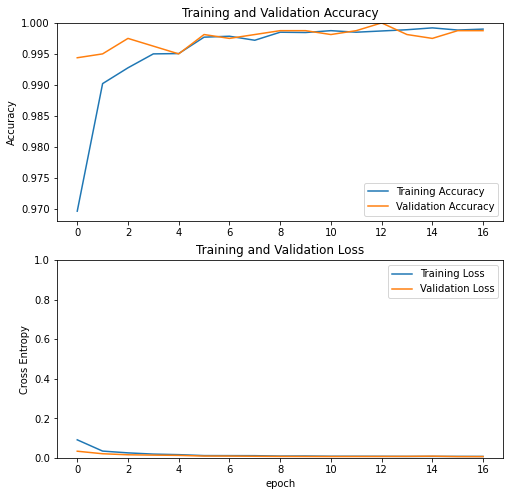

In [7]:
acc = history.history['binary_accuracy']
val_acc = history.history['val_binary_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()


In [8]:
# test model
model.evaluate(test_ds)

31/31 [==============================] - 43s 1s/step - loss: 0.0173 - binary_accuracy: 0.9929


[0.01726478338241577, 0.992943525314331]

In [9]:
# unfreeze all the layers
base_model.trainable = True

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.00001),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.BinaryAccuracy()]
)

In [11]:
# Using EarlyStopping, end training when val_accuracy is not improved for 4 consecutive times
early_stopping = keras.callbacks.EarlyStopping(monitor='val_binary_accuracy',mode='max',
                                patience=4,restore_best_weights=True)

# Using ReduceLROnPlateau, the learning rate is reduced by half when val_accuracy is not improved for 2 consecutive times
lr_scheduler = keras.callbacks.ReduceLROnPlateau(monitor='val_binary_accuracy',factor=0.5,
                                patience=2,verbose=1)

# training
history = model.fit(train_ds,batch_size=32,epochs=30,
        validation_data=val_ds,callbacks=[early_stopping,lr_scheduler])

Epoch 1/30
313/313 [==============================] - 2040s 7s/step - loss: 0.0147 - binary_accuracy: 0.9954 - val_loss: 0.0063 - val_binary_accuracy: 0.9975 - lr: 1.0000e-05
Epoch 2/30
313/313 [==============================] - 2336s 7s/step - loss: 0.0044 - binary_accuracy: 0.9988 - val_loss: 0.0014 - val_binary_accuracy: 0.9987 - lr: 1.0000e-05
Epoch 3/30
313/313 [==============================] - 3378s 11s/step - loss: 0.0024 - binary_accuracy: 0.9994 - val_loss: 7.0518e-04 - val_binary_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 4/30
313/313 [==============================] - 2241s 7s/step - loss: 0.0049 - binary_accuracy: 0.9984 - val_loss: 1.1480e-04 - val_binary_accuracy: 1.0000 - lr: 1.0000e-05
Epoch 5/30
313/313 [==============================] - ETA: 0s - loss: 0.0013 - binary_accuracy: 0.9995
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
313/313 [==============================] - 2169s 7s/step - loss: 0.0013 - binary_accuracy: 0.9995 - val_loss: 3.

In [12]:
# test model 
model.evaluate(test_ds)

# Our model achieved 99.89% accuracy on test data.

31/31 [==============================] - 45s 1s/step - loss: 0.0083 - binary_accuracy: 0.9980


[0.008265872485935688, 0.9979838728904724]

In [14]:
# save model
model.save('VGG19-Face Mask Detection.h5')

In [3]:
model = keras.models.load_model('C:/Users/LENOVO/Documents/skripsi/program/VGG19-Face Mask Detection.h5')

In [4]:
# loading haarcascade_frontalface_default.xml
face_model = cv2.CascadeClassifier('C:/Users/LENOVO/Documents/skripsi/program/input/haarcascades/haarcascade_frontalface_default.xml')

In [5]:
mask_label = {0:'MASK',1:'NO MASK'}
dist_label = {0:(0,255,0),1:(255,0,0)} # rectangle color

In [6]:
def plot_image(image,subplot):
    plt.subplot(*subplot)
    plt.imshow(image)
    plt.xticks([])
    plt.yticks([])
    plt.show

def predict_image(image_dir):
    img = cv2.imread(image_dir)
    img = cv2.cvtColor(img, cv2.IMREAD_GRAYSCALE)
    
    #returns a list of (x,y,w,h) tuples
    faces = face_model.detectMultiScale(img,scaleFactor=1.1, minNeighbors=4)
    
    out_img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    plt.figure(figsize=(10,10))
    plot_image(out_img,(1,2,1))
    
    for i in range(len(faces)):
        (x,y,w,h) = faces[i]
        crop = out_img[y:y+h,x:x+w]
        crop = cv2.resize(crop,(128,128))
        crop = np.reshape(crop,[1,128,128,3])/255.0
        mask_result = model.predict(crop).argmax()
#         cv2.putText(out_img,mask_label[mask_result.argmax()],(x, y+90),cv2.FONT_HERSHEY_SIMPLEX,0.5,dist_label[label[i]],2)
        cv2.rectangle(out_img,(x,y),(x+w,y+h),dist_label[mask_result],1)
    
    plot_image(out_img,(1,2,2))

1/1 [==============================] - 0s 87ms/step


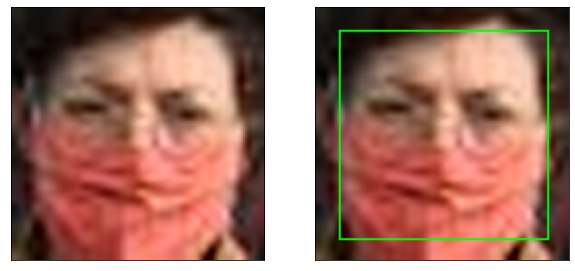

In [13]:
# predict_image('C:/Users/LENOVO/Documents/skripsi/program/input/face-mask-detection/images/maksssksksss244.png')
predict_image("C:/Users/LENOVO/Documents/skripsi/program/input/Dataset/with_mask/3.png")

1/1 [==============================] - 0s 85ms/step


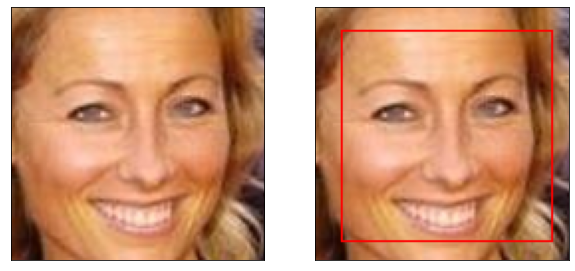

In [14]:
predict_image("C:/Users/LENOVO/Documents/skripsi/program/input/Dataset/without_mask/3.png")

1/1 [==============================] - 0s 73ms/step


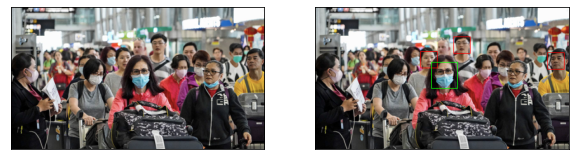

In [21]:
predict_image('C:/Users/LENOVO/Documents/skripsi/program/input/face-mask-detection/images/maksssksksss388.png')